<h2> Understanding DICOM data - Loading, Attributes and Visualization</h2>

<h3> 1. Loading the data </h3> 
Function to load the dataset and collect it in series of useful, "readable" data:

In [216]:
from pathlib import Path
import collections
import os
import pydicom

def is_dicom(path: Path) -> bool:
    # fast sniff: "DICM" at byte offset 128 (common but not guaranteed)
    try:
        with open(path, "rb") as fp:
            fp.seek(128)
            return fp.read(4) == b"DICM"
    except OSError:
        return False

def find_dicom_series(root_or_files):
    """
    Accept either:
      - a folder path (walk recursively), OR
      - an iterable of file paths
    Return: dict[SeriesInstanceUID] -> list[Path]
    """
    series = collections.defaultdict(list)

    if isinstance(root_or_files, (str, os.PathLike, Path)):
        root = Path(root_or_files)
        it = (p for p in root.rglob("*") if p.is_file())
    else:
        it = (Path(p) for p in root_or_files)

    for f in it:
        if not f.is_file():
            continue
        if not is_dicom(f):
            continue

        try:
            ds = pydicom.dcmread(f, stop_before_pixels=True, force=True) # only read metadata, ignore image data for now
        except Exception:
            continue

        uid = ds.get("SeriesInstanceUID") or ds.get("SOPInstanceUID")
        series[str(uid)].append(f)

    return series

In [217]:
series = find_dicom_series(r"/data0/markok/data_pet/PET_CT_brain_UKC_Nevro/Gasper_prvi_paket/") #select the dataset here
for uid, files in series.items():
        # read metadata from the first file of this series
        ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)                
        #Some metadata displayed
        print(f"Series UID: {uid}")
        print(f"Study Instance UID: {getattr(ds, 'StudyInstanceUID', 'N/A')}")
        print(f"Number of files: {len(files)}")
        print(f"Modality: {getattr(ds, 'Modality', 'N/A')}")
        print(f"Series Description: {getattr(ds, 'SeriesDescription', 'N/A')}")
        print("---")


Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000009
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000006
Number of files: 148
Modality: CT
Series Description: AC   CT Brain  3.0  Hf38
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000613
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310
Number of files: 148
Modality: PT
Series Description: PET Brain uncorrected
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000160
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000006
Number of files: 148
Modality: PT
Series Description: PET Brain uncorrected
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000313
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310
Number of files: 148
Modality: CT
Series Description: AC   CT Brain  3.0  Hf38
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000463
Study Instan

Each series contains 148 files, and each file is a different slice of the brain, taken upon patient imaging. 

Next step is to separate the series per patient, based on their unique Study instance value:

In [218]:
def group_series_by_patient(series_dict):
    """
    series_dict : {SeriesUID: [filepaths]}
    returns     : {PatientKey: {StudyUID: [SeriesUID, ...]}}
    """
    patients = collections.defaultdict(lambda: collections.defaultdict(list))

    for series_uid, files in series_dict.items():
        if not files:
            print(f"[WARNING] No files for series {series_uid}, skipping.")
            continue

        try:
            ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)
        except Exception as e:
            print(f"[WARNING] Could not read {files[0]}: {e}")
            continue

        def safe_get(tag):
            val = getattr(ds, tag, None)
            return val if val not in (None, "", " ") else None

        # Stable patient key, robust to anonymisation
        date  = getattr(ds, "StudyDate", "NODATE")
        time  = getattr(ds, "StudyTime", "000000")[:6]
        patient_key = (
            safe_get("PatientID") or #usually empty due to anonymisation
            safe_get("StudyInstanceUID") or # this one is the key one 
            f"{date}_{time}"
        )
        
        study_uid = safe_get("StudyInstanceUID")
        if study_uid is None:
            print(f"[WARNING] Missing StudyInstanceUID for series {series_uid}, skipping.")
            continue

        patients[patient_key][study_uid].append(series_uid)

    return patients


Execution Group Series per patient: 

In [219]:
patients = group_series_by_patient(series)
print(f"Found {len(patients)} patients")

Found 125 patients


<h3> 2. DICOM Attributes </h3>

It is important to first understand all the attributes that a DICOM dataset consists of. Therefore, a list of all tags per imaging process is provided:

In [220]:
patient_key = list(patients.keys())[0]
studies = patients[patient_key]
study_uid = list(studies.keys())[0]
series_uids = studies[study_uid]
series_uid = series_uids[0]
file_path = series[series_uid][0]
ds = pydicom.dcmread(file_path, stop_before_pixels=True, force=True)
for elem in ds:
    print(elem)

(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SPI']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000072
(0008,0020) Study Date                          DA: '20250220'
(0008,0021) Series Date                         DA: '20250220'
(0008,0022) Acquisition Date                    DA: '20250220'
(0008,0023) Content Date                        DA: '20250220'
(0008,002A) Acquisition DateTime                DT: '20250220144618.626000'
(0008,0030) Study Time                          TM: '143953.971000'
(0008,0031) Series Time                         TM: '144627.853000'
(0008,0032) Acquisition Time                    TM: '144618.626000'
(0008,0033) Content Time                        TM: '144618.626000'
(0008,0050) Accession Number                    SH: 'F01

Group the files per patient. Structural display of the metadata:

In [221]:
patients = group_series_by_patient(series)
print(f"Found {len(patients)} patients")

print(f"{'Serie count:':>14} | {'Type':<3} | {'Series Description':<35} | Slices | Dimension")
for pat_nr, (patient_key, studies) in enumerate(patients.items(), start=1):
    print(f"Patient {pat_nr}:    (PatientID: {patient_key})")
    for modality, study_des in studies.items():
        for ser_idx, series_uid in enumerate(study_des, start=1):
            ds = pydicom.dcmread(series[series_uid][0], stop_before_pixels=True, force=True)

            mod = getattr(ds, "Modality", "")
            ser = getattr(ds, "SeriesDescription", "")
            stu = getattr(ds, "StudyDescription", "")
            slices_nr = len(series[series_uid])
            rows = int(getattr(ds, "Rows", -1))
            cols = int(getattr(ds, "Columns", -1))

            print(f"     {ser_idx:>8}. |  {mod:<4}| {ser:<35} |  {slices_nr}   | {rows} x {cols} ")

Found 125 patients
  Serie count: | Type | Series Description                  | Slices | Dimension
Patient 1:    (PatientID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000006)
            1. |  CT  | AC   CT Brain  3.0  Hf38            |  148   | 512 x 512 
            2. |  PT  | PET Brain uncorrected               |  148   | 400 x 400 
Patient 2:    (PatientID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310)
            1. |  PT  | PET Brain uncorrected               |  148   | 400 x 400 
            2. |  CT  | AC   CT Brain  3.0  Hf38            |  148   | 512 x 512 
            3. |  PT  | PET Brain                           |  148   | 400 x 400 
Patient 3:    (PatientID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000762)
            1. |  CT  | AC   CT Brain  3.0  Hf38            |  148   | 512 x 512 
            2. |  PT  | PET Brain                           |  148   | 400 x 400 
            3. |  PT  | PET Brain uncorrected               |  148   | 

<h3>3. Vizualization - working with images </h3>

Once the attributes are known, better work with visualization is available. To begin with, data needs to be sorted - slices, based on their z-axis tag

In [222]:
import numpy as np

def sort_instances(files):
    """Sort DICOM instance files into slice order. Returns list of pydicom datasets."""
    dsets = []
    for f in files:
        try:
            ds = pydicom.dcmread(f, force=True)
            dsets.append(ds)
        except Exception:
            continue

    def z_key(ds):
        ipp = getattr(ds, "ImagePositionPatient", None)  
        if ipp is not None and len(ipp) == 3:
            return float(ipp[2])
        return float(getattr(ds, "InstanceNumber", 0))

    dsets.sort(key=z_key)
    return dsets

def load_volume_from_series(files, apply_rescale=True):
    """Load a DICOM series into a 3D numpy array (Z, Y, X)."""
    dsets = sort_instances(files) # get sorted pydicom datasets for this series on the axis of acquisition (Z) 
    if not dsets:
        raise ValueError("No readable DICOM instances in this series.")

    vol = []
    for ds in dsets:
        arr = ds.pixel_array.astype(np.float32)

        if apply_rescale:
            slope = float(getattr(ds, "RescaleSlope", 1.0))
            inter = float(getattr(ds, "RescaleIntercept", 0.0))
            arr = arr * slope + inter

        vol.append(arr)

    vol = np.stack(vol, axis=0)  # (Z, Y, X) classical
    return vol, dsets[0]         # return first ds for metadata

In [223]:
# Check series if it works, and 
series_uids = list(series.keys())
idx = 148*2 # pick index you want:
series_uid = series_uids[idx]
files = series[series_uid]
loaded_series = load_volume_from_series(files) # this will load the whole volume into memory, be careful with large series!
print("Loaded series shape (Z, Y, X):", loaded_series[0].shape)
print("Loaded series UID:", loaded_series[1].SeriesInstanceUID)
print("Modality:", loaded_series[1].get("Modality", ""))
print("Series description:", loaded_series[1].get("SeriesDescription", ""))

Loaded series shape (Z, Y, X): (148, 400, 400)
Loaded series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100044609
Modality: PT
Series description: PET Brain uncorrected


In [245]:
def series_per_patient(patients_sorted, series_dict, patient_key):
    """
    Returns dict with keys: 'CT', 'PET_uncorrected', 'PET'
    Values are series_uids (or None if not found).
    """
    ct_uid = None
    pet_u = None
    pet_c = None

    studies = patients_sorted[patient_key]
    # iterate studies in order
    for study_uid, series_uids in studies.items():
        for suid in series_uids:
            files = series_dict.get(suid, [])
            if not files:
                continue

            ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)
            mod = getattr(ds, "Modality", "")
            desc = getattr(ds, "SeriesDescription", "") 
            rows = int(getattr(ds, "Rows", -1))
            cols = int(getattr(ds, "Columns", -1))

            if mod == "CT" and ct_uid is None:
                ct_uid = suid

            if mod == "PT":
                if "uncorrected" in desc.lower():
                    if pet_u is None:
                        pet_u = suid
                else:
                    if pet_c is None:
                        pet_c = suid


    return {"CT": ct_uid, "PET_uncorrected": pet_u, "PET": pet_c}

In [246]:
# use the function to pick series for a patient
patient_keys = list(patients.keys())
idx = 1 # pick patient index you want
one_patient_key = patient_keys[idx]
picked_series = series_per_patient(patients, series, one_patient_key)
print(f"Picked series for patient {idx+1}: UID {one_patient_key}:")
for key, suid in picked_series.items():
    print(f"  {key}: {suid} ")


Picked series for patient 2: UID 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310:
  CT: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000313 
  PET_uncorrected: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000613 
  PET: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000463 


In [ ]:
import matplotlib.pyplot as plt

def show_one_patient(patient_key, patients_sorted, series_dict, series_files_dict, slice_index=None, patient_label=None):
    picked = series_per_patient(patients_sorted, series_files_dict, patient_key)

    if picked["CT"] is None and picked["PET_uncorrected"] is None and picked["PET"] is None:
        raise ValueError("No CT/PET series found for this patient.")

    vols = {}
    metas = {}

    # Load volumes (CT rescale to HU is useful; PET rescale may also be useful)
    if picked["CT"]:
        vols["CT"], metas["CT"] = load_volume_from_series(series_files_dict[picked["CT"]], apply_rescale=True)
    if picked["PET_uncorrected"]:
        vols["PET uncorrected"], metas["PET uncorrected"] = load_volume_from_series(series_files_dict[picked["PET_uncorrected"]], apply_rescale=True)
    if picked["PET"]:
        vols["PET"], metas["PET"] = load_volume_from_series(series_files_dict[picked["PET"]], apply_rescale=True)

    # choose slice index = middle slice (based on CT if exists, else first available)
    ref_key = "CT" if "CT" in vols else next(iter(vols.keys()))
    z = vols[ref_key].shape[0]
    if slice_index is None:
        slice_index = z // 2
    slice_index = max(0, min(slice_index, z - 1))

    # plot
    keys_in_order = ["CT", "PET uncorrected", "PET"]
    present = [k for k in keys_in_order if k in vols]

    fig, axes = plt.subplots(1, len(present), figsize=(5 * len(present), 5))
    if len(present) == 1:
        axes = [axes]

    for ax, k in zip(axes, present):
        img = vols[k][slice_index]

        # simple display defaults:
        if k == "CT":
            # typical brain-ish window (you can change)
            ax.imshow(img, cmap="gray", vmin=-100, vmax=200)
        else:
            ax.imshow(img, cmap="gray")

        ds0 = metas[k]
        desc = getattr(ds0, "SeriesDescription", "")
        ax.set_title(f"{k}\n{desc}".strip())
        title = patient_label if patient_label is not None else patient_key

    plt.suptitle(f"{title}   |   slice {slice_index}", y=1.07, fontsize=16) 
    plt.tight_layout()
    plt.show()

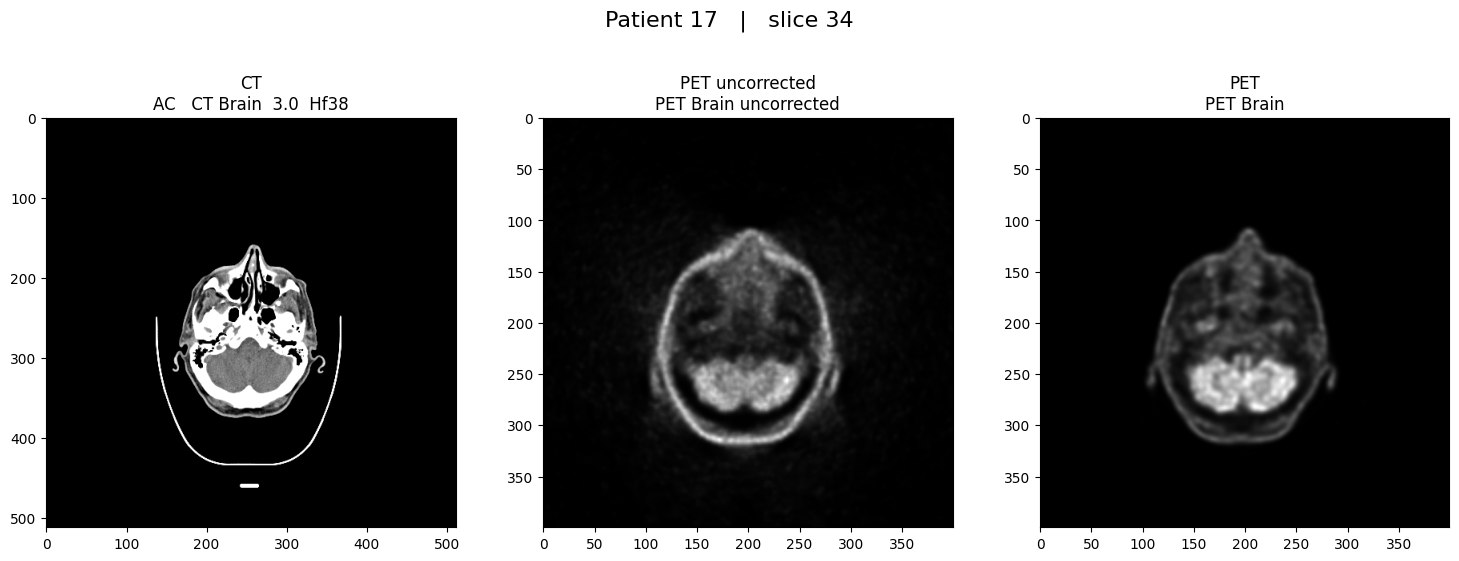

In [ ]:
patient_keys = list(patients.keys())

#Choose a patient index
idx = 16
one_patient_key = patient_keys[idx] 

#Choose a slice index 
slc_idx = 34

show_one_patient(
    patient_key=one_patient_key,
    patients_sorted=patients,
    series_dict=None,               # not used in this version
    series_files_dict=series,       # your {series_uid: [files]}
    slice_index=slc_idx,
    patient_label =f"Patient {idx+1}"             # middle slice
)

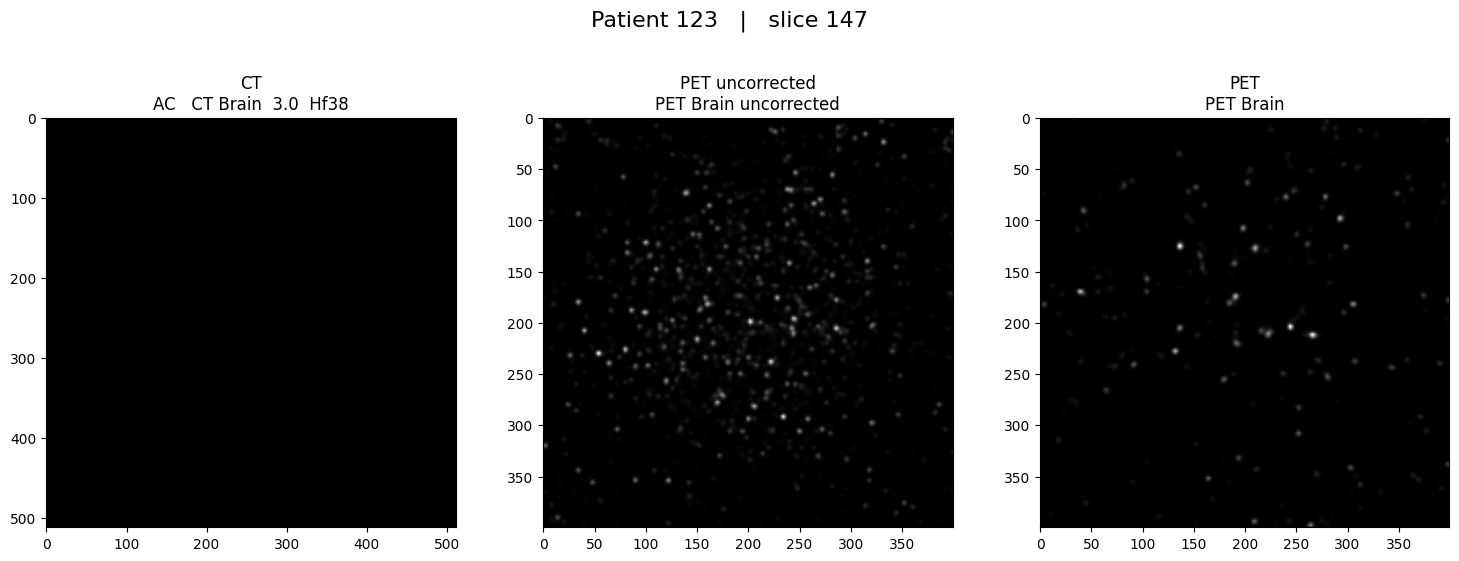

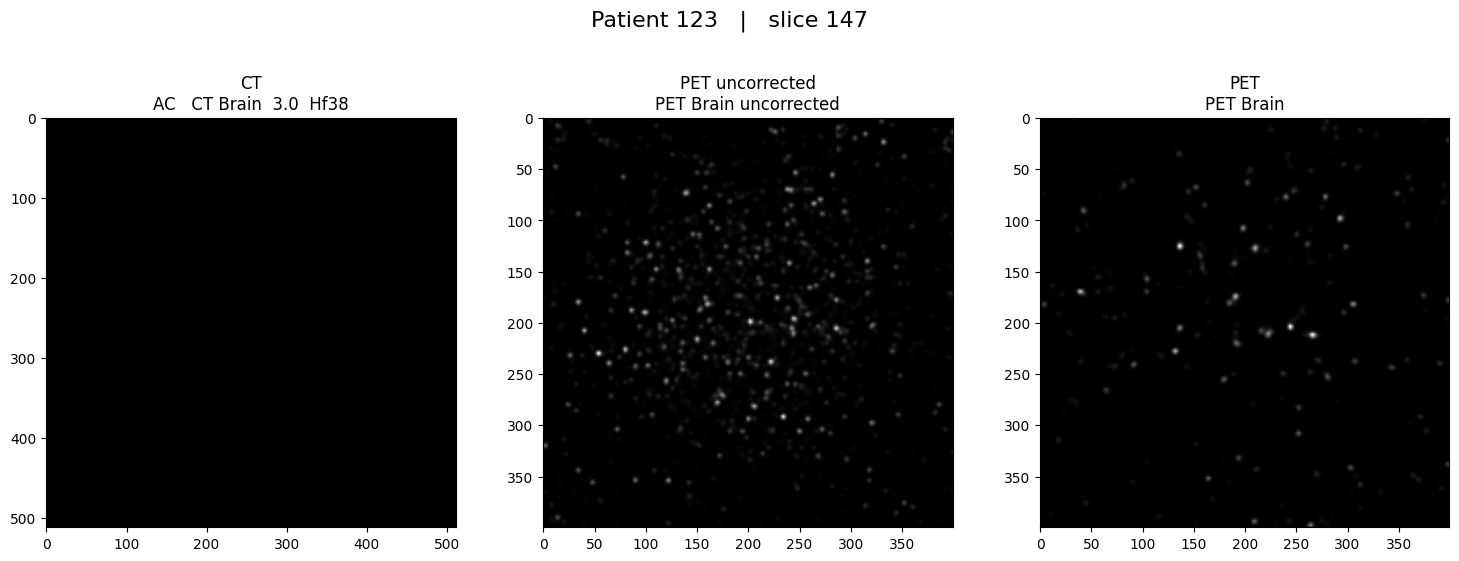

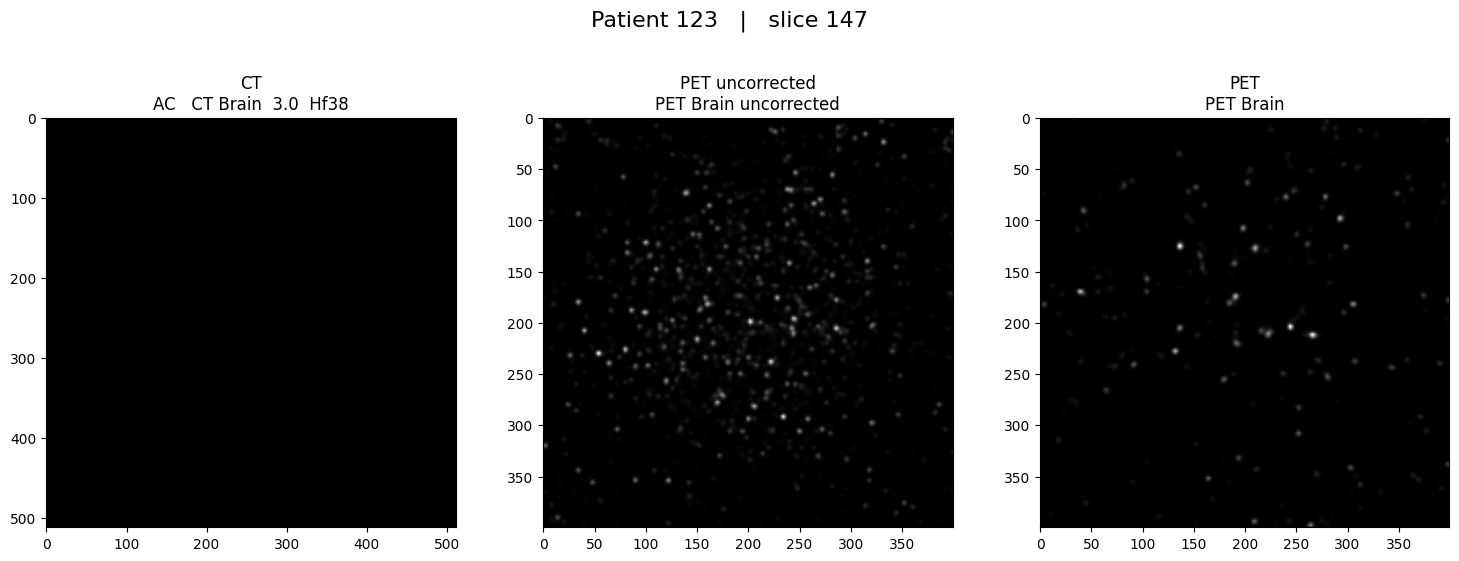

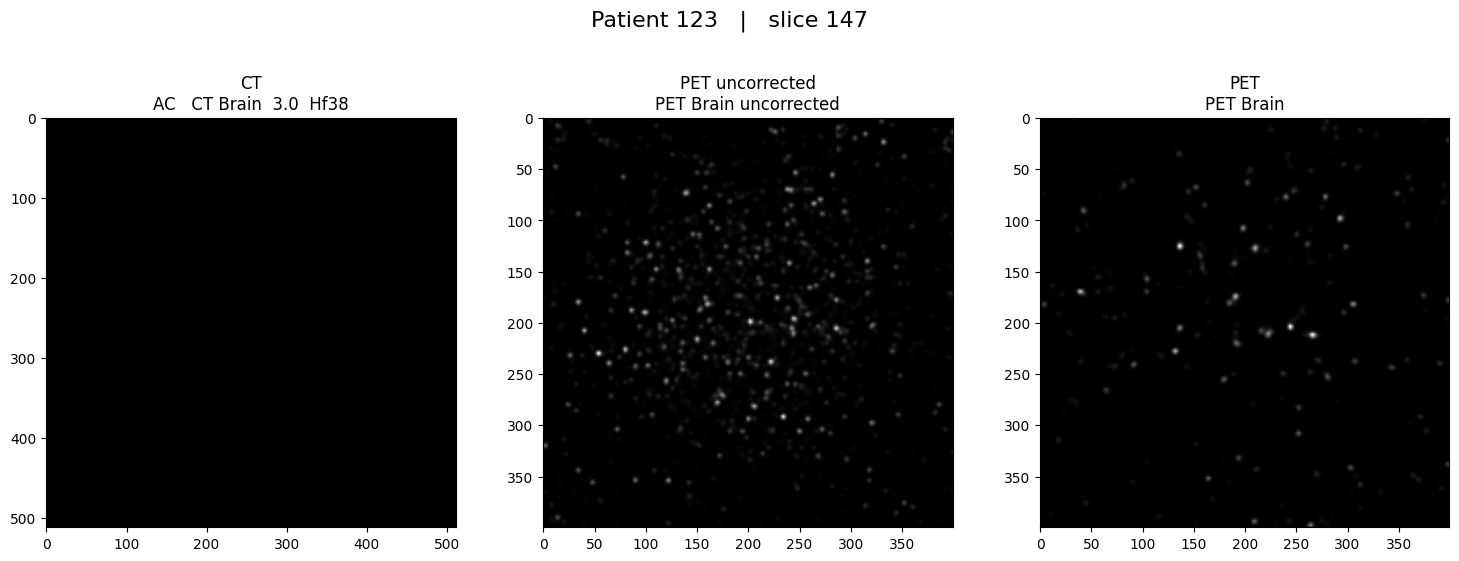

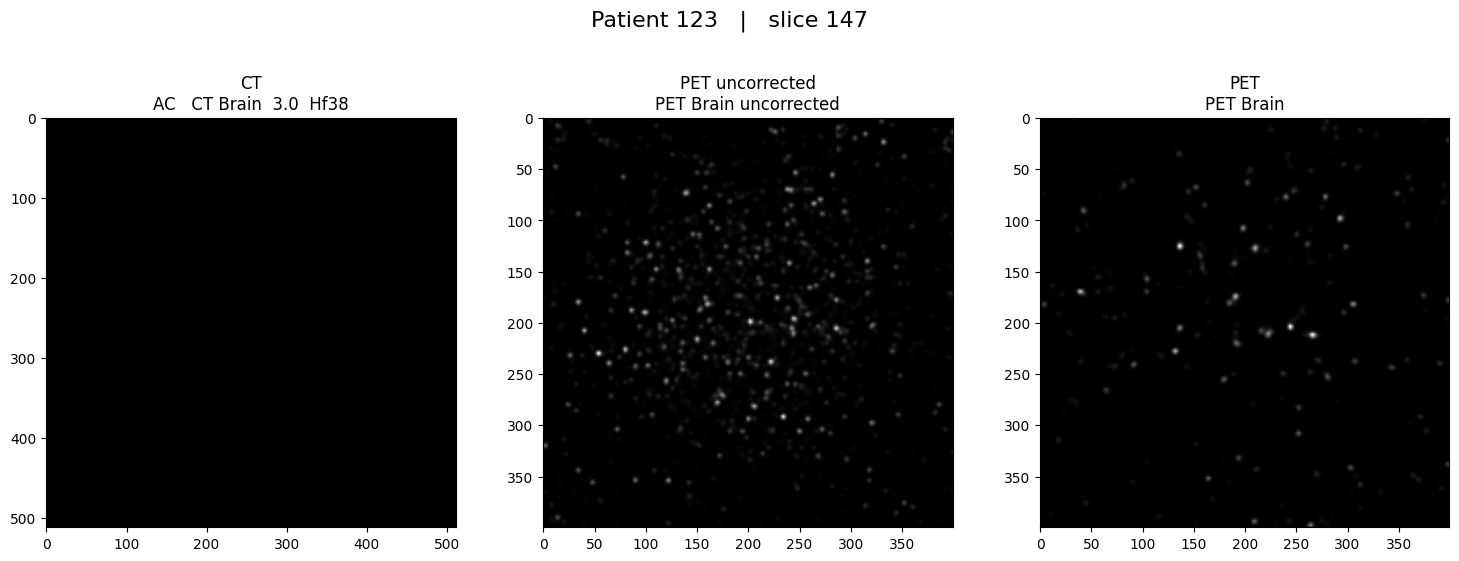

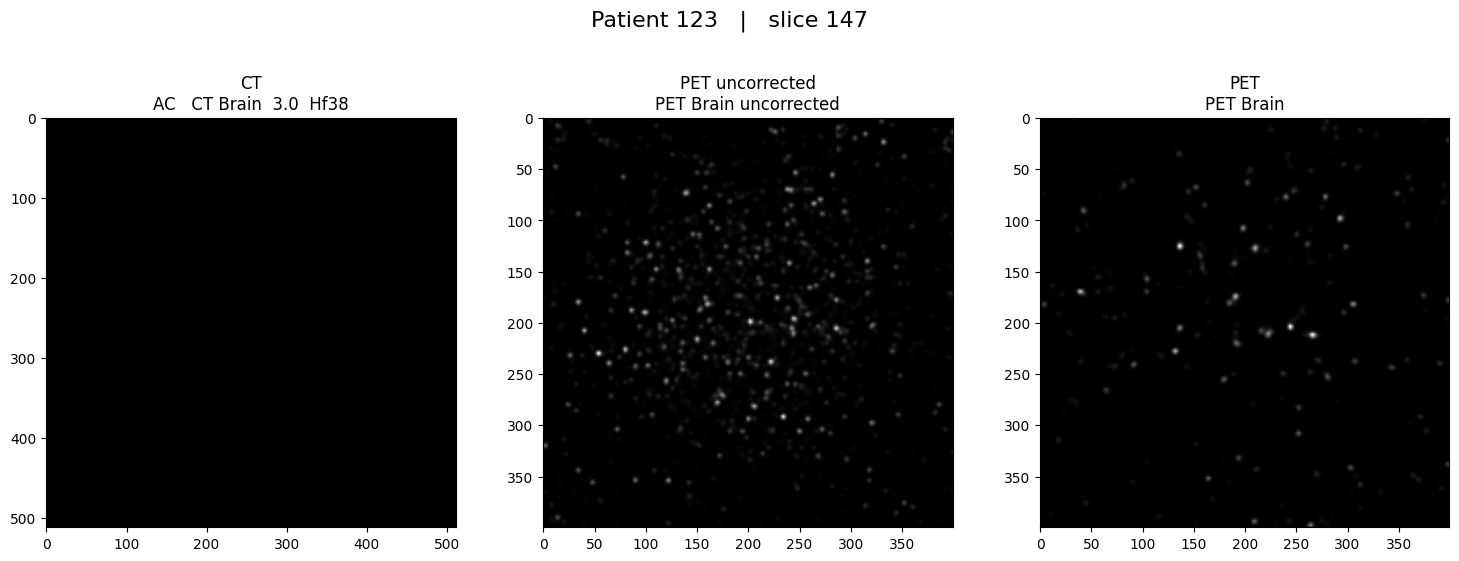

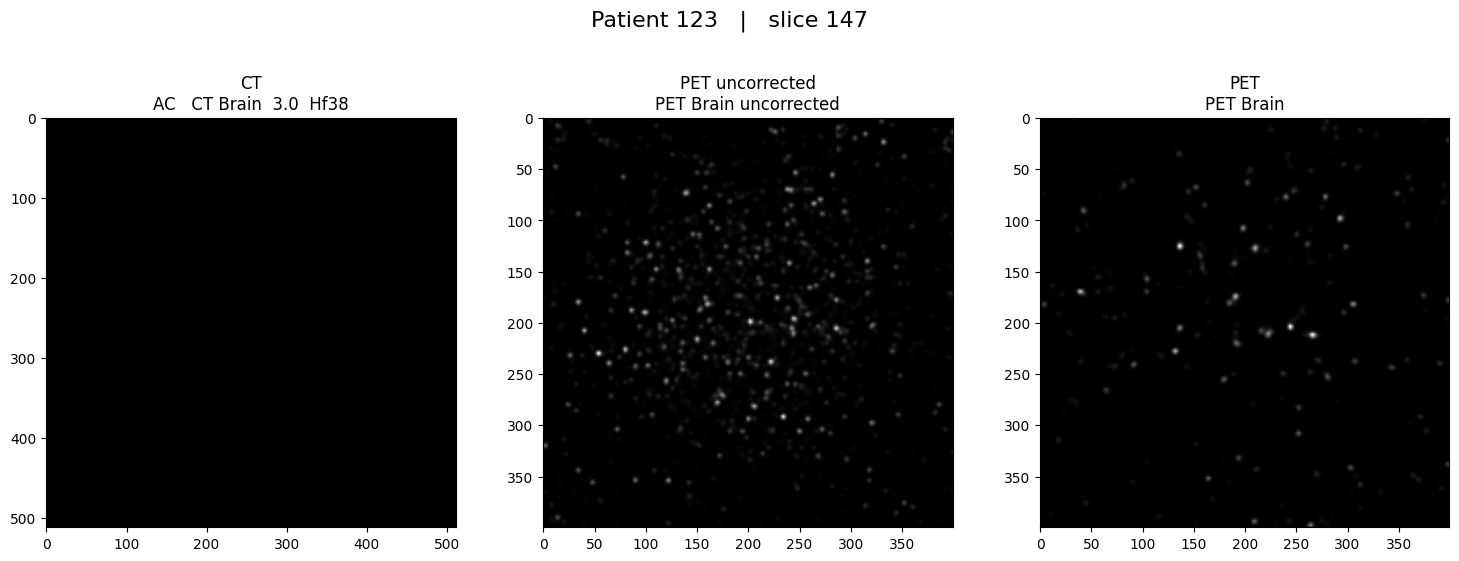

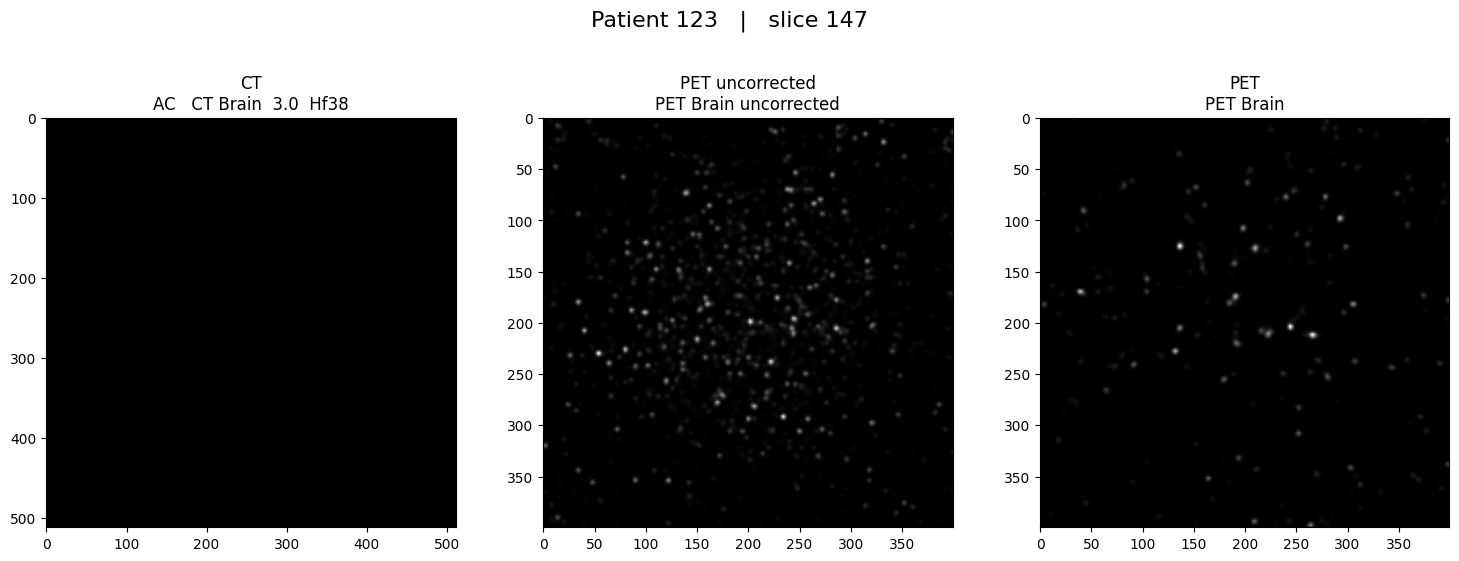

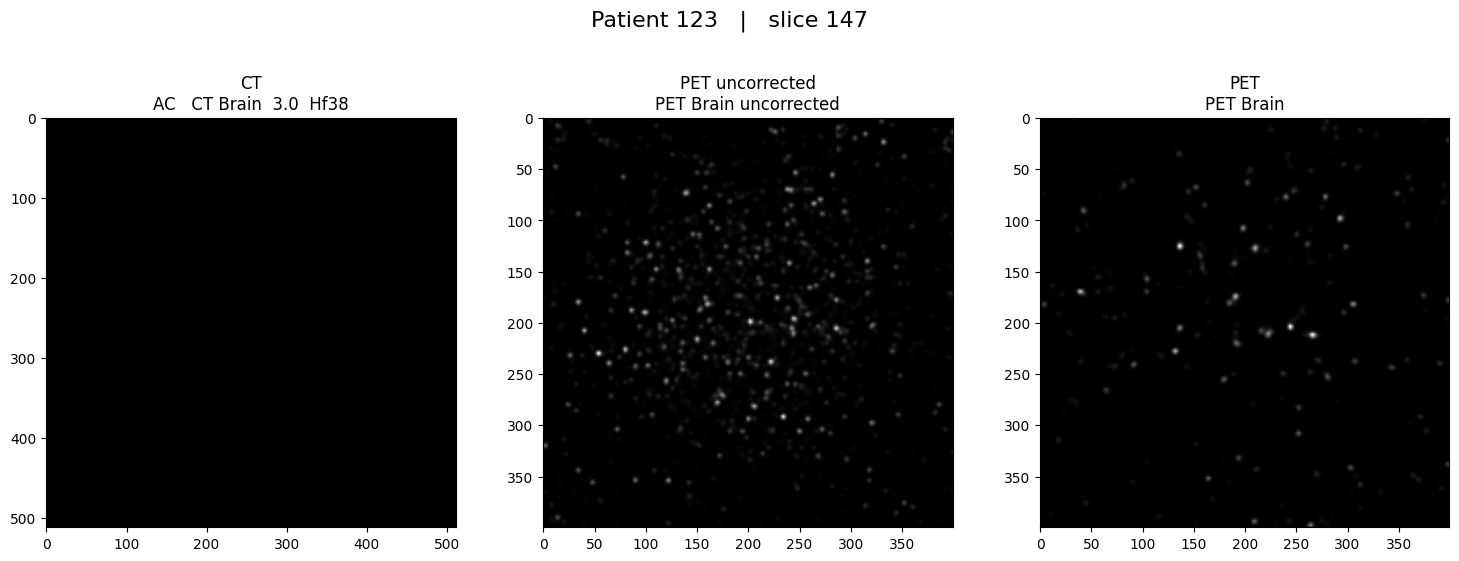

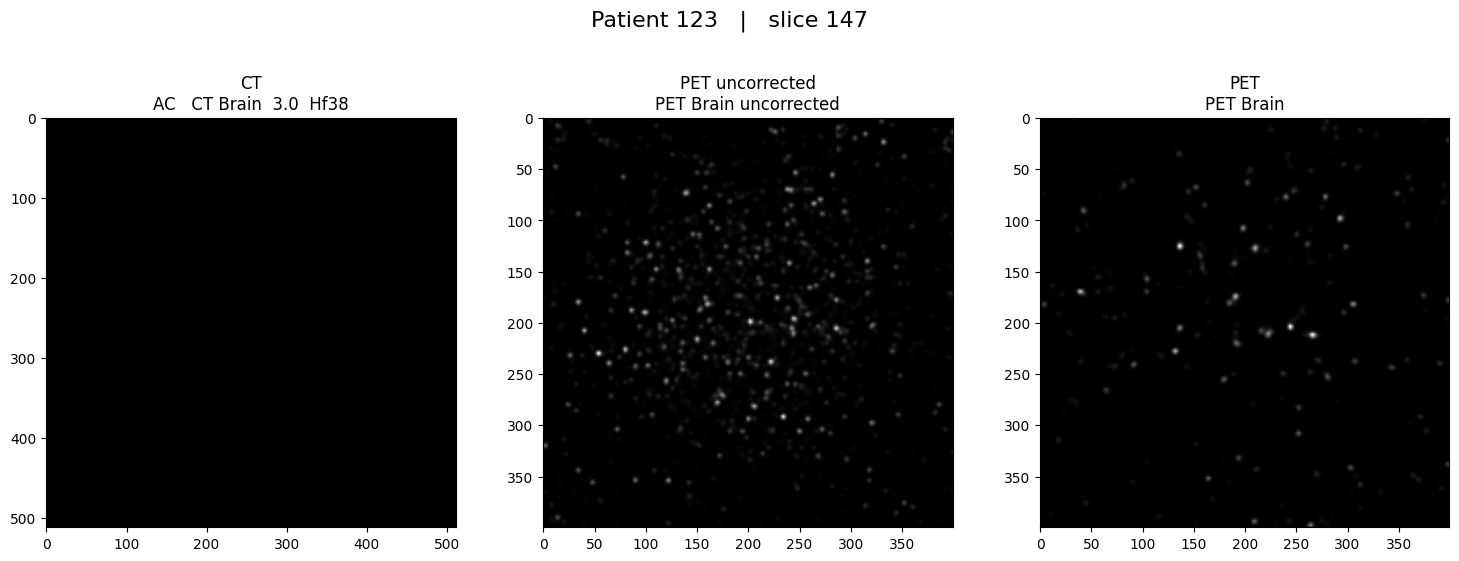

In [ ]:
for slc in range(slc_idx-40,slc_idx, 4):
    show_one_patient(
        patient_key=one_patient_key,
        patients_sorted=patients,
        series_dict=None,               # not used in this version
        series_files_dict=series,       # your {series_uid: [files]}
        slice_index=slc,
        patient_label =f"Patient {idx+1}"             # middle slice
    )